# Data Preprocessing in Python

Data preprocessing is the first step in any data analysis or machine learning pipeline. It involves cleaning, transforming and organizing raw data to ensure it is accurate, consistent and ready for modeling. It has a big impact on model building such as:

- Clean and well-structured data allows models to learn meaningful patterns rather than noise.

- Properly processed data prevents misleading inputs, leading to more reliable predictions.

- Organized data makes it simpler to create useful inputs for the model, enhancing model performance.

- Organized data supports better Exploratory Data Analysis (EDA), making patterns and trends more interpretable.

# Steps-by-Step implementation

Let's implement various preprocessing features,

## Step 1: Import Libraries and Load Dataset

We prepare the environment with libraries like pandas, numpy, scikit learn, matplotlib and seaborn for data manipulation, numerical operations, visualization and scaling. Load the dataset for preprocessing.

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../Datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 2: Inspect Data Structure and Check Missing Values

We understand dataset size, data types and identify any incomplete (missing) data that needs handling.

- df.info(): Prints concise summary including count of non-null entries and data type of each column.

- df.isnull().sum(): Returns the number of missing values per column.

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [57]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Step 3: Statistical Summary and Visualizing Outliers

Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.

- df.describe(): Computes count, mean, std deviation, min/max and quartiles for numerical columns.

- Boxplots: Visualize spread and detect outliers using matplotlib’s boxplot().

In [58]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


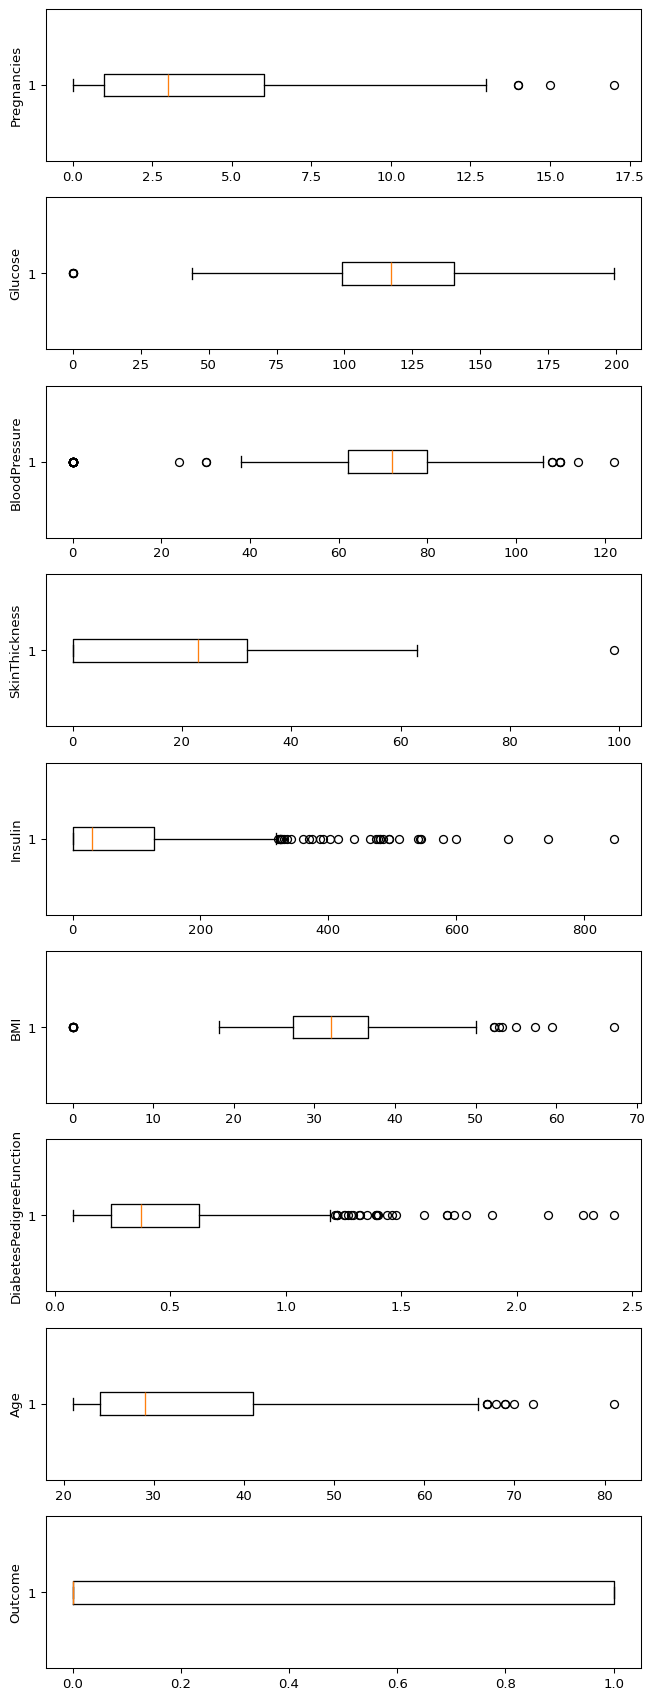

In [59]:
fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95) # Create a figure with 9 subplots (one per column), stacked vertically in a single column
# len(df.columns) = 9 rows, 1 = 1 column, figsize=(7, 18) = 7in wide × 18in tall, dpi=95 = pixel density

for i, col in enumerate(df.columns):    # Loop through each column with its index — i=0 to 8, col = column name
    axs[i].boxplot(df[col], vert=False) # Draw a horizontal boxplot of that column's values in subplot i
    axs[i].set_ylabel(col)   # Label the y-axis with the column name (e.g. "Glucose", "BMI")
plt.tight_layout()           # Auto-adjust spacing so subplot labels don't overlap each other
plt.show()                   # Render and display the final figure

## What the boxplot itself shows you for each column:

Each box visualizes five statistics at once - the left whisker is the minimum (excluding outliers), the left edge of the box is Q1 (25th percentile), the vertical line inside the box is the median, the right edge is Q3 (75th percentile), the right whisker is the maximum, and any dots beyond the whiskers are outliers.

# Step 4: Remove Outliers Using the Interquartile Range (IQR) Method

Remove extreme values beyond a reasonable range to improve model robustness.

- IQR = Q3 (75th percentile) – Q1 (25th percentile).

- Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.

- Calculate lower and upper bounds for each column separately.

- Filter data points to keep only those within bounds.

In [60]:
# This code is an IQR-based outlier removal on Insulin
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]

In [61]:
## First 5 rows
print(clean_df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [62]:
# Specific rows by index
print(clean_df.iloc[0:20]) # rows 0–19

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
1             1       85             66             29        0  26.6   
2             8      183             64              0        0  23.3   
3             1       89             66             23       94  28.1   
4             0      137             40             35      168  43.1   
5             5      116             74              0        0  25.6   
6             3       78             50             32       88  31.0   
7            10      115              0              0        0  35.3   
9             8      125             96              0        0   0.0   
10            4      110             92              0        0  37.6   
11           10      168             74              0        0  38.0   
12           10      139             80              0        0  27.1   
14            5      166             72            

Filtering result:

- Rows removed: 34 (values above 318)

- Max Insulin before: 846 → after: 318

- Mean Insulin before: 79.80 → after: 62.33

- Rows remaining: 734 of 768

# Step 5: Correlation Analysis

Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.

- df.corr(): Computes pairwise correlation coefficients between columns.

- Heatmap via seaborn visualizes correlation matrix clearly.

- Sorting correlations with corr['Outcome'].sort_values() highlights features most correlated with the target.

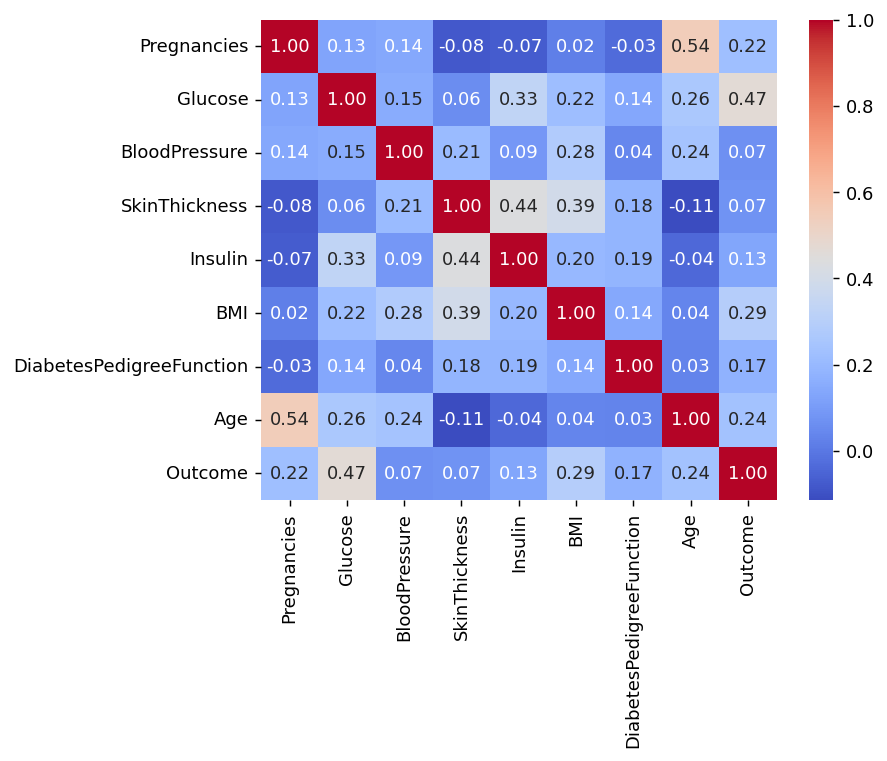

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [63]:

corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['Outcome'].sort_values(ascending=False))

Key takeaways from the correlation analysis:

Glucose is by far the strongest predictor of diabetes (r = 0.47) — nearly twice as strong as the next best feature. BMI, Age, and Pregnancies follow with moderate correlations in the 0.22–0.29 range. BloodPressure and SkinThickness are surprisingly weak predictors (r ≈ 0.07).

Two notable inter-feature correlations worth watching: SkinThickness–Insulin (r = 0.44) and Age–Pregnancies (r = 0.54). The latter is expected — older patients have had more pregnancies — but it means these two features carry overlapping information, which can affect models sensitive to multicollinearity (like logistic regression).

What coolwarm maps to in seaborn: red = strong positive, white = near zero, blue = negative — the same logic as the heatmap above.

# Step 6: Visualize Target Variable Distribution

Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

- plt.pie(): Pie chart to display proportion of each class in the target variable 'Outcome'.

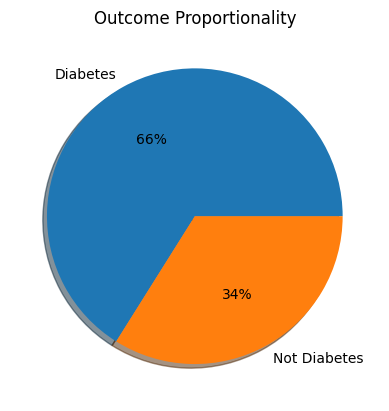

In [64]:
plt.pie(clean_df['Outcome'].value_counts(),
        labels=['Diabetes', 'Not Diabetes'],
        autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')       
plt.show()

Code breakdown — what each argument does:

value_counts() counts 0s and 1s in Outcome, returning [485, 249] — the slice sizes. 

labels=['Diabetes', 'Not Diabetes'] maps those counts to names 

(note: value_counts() returns the majority class first, so 0 maps to 'Diabetes' here — the labels are actually 
swapped from what you'd expect, worth double-checking). 

autopct='%.f%%' formats each slice with a whole-number percentage and a % sign. shadow=True adds a drop shadow behind the pie.

What the data tells you after outlier removal:

| Class        | Before (768 rows) | After `clean_df` (734 rows) |
| ------------ | ----------------- | --------------------------- |
| Not Diabetes | 500 (65.1%)       | 485 (66.1%)                 |
| Diabetes     | 268 (34.9%)       | 249 (33.9%)                 |




Removing the 34 insulin outliers slightly reduced the diabetic class — those extreme insulin values were disproportionately from diabetic patients, which makes clinical sense.

# Step 7: Separate Features and Target Variable

Prepare independent variables (features) and dependent variable (target) separately for modeling.

- df.drop(columns=[...]): Drops the target column from features.

- Direct column selection df['Outcome'] selects target column.

In [65]:
X = df.drop(columns=['Outcome'])  # shape: (768, 8) — all input features
y = df['Outcome']                  # shape: (768,)  — 0 or 1 labels

# Step 8: Feature Scaling: Normalization and Standardization

Scale features to a common range or distribution, important for many ML algorithms sensitive to feature magnitudes.

1. Normalization (Min-Max Scaling): Rescales features between 0 and 1. Good for algorithms like k-NN and neural networks.

- Class: MinMaxScaler from sklearn.

- .fit_transform(): Learns min/max from data and applies scaling.

In [66]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print(X_normalized[:5])

[[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
  0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 0.29292929 0.         0.39642325
  0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 0.         0.         0.34724292
  0.25362938 0.18333333]
 [0.05882353 0.44723618 0.54098361 0.23232323 0.11111111 0.41877794
  0.03800171 0.        ]
 [0.         0.68844221 0.32786885 0.35353535 0.19858156 0.64232489
  0.94363792 0.2       ]]


The code - line by line:

- scaler = MinMaxScaler() creates a scaler object from sklearn. It doesn't touch any data yet — just sets up the tool with its default range of [0, 1].

- X_normalized = scaler.fit_transform(X) does two things in one step: fit learns the min and max of each column from X, then transform applies the formula to every value:

- print(X_normalized[:5]) prints the first 5 rows of the result as a NumPy array — no column names, just raw numbers in the original column order.


2. Standardization: Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features.

Class: StandardScaler from sklearn.

In [67]:
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]


## Advantages

- Cleans and organizes raw data for better analysis.

- Removes noise and irrelevant data, leading to more precise predictions.

- Handles outliers and redundant features, which reduces overfitting.

- Scaling data helps models train faster by reducing computation time.

- Converts data into formats suitable for machine learning models.